# Lab 1 - Intrinsic Explainable Models

**How the lab works**

- The questions are divided into three levels.
  - **[Basic]**: if your group completes all Basic questions of a lab correctly, you get a 6 (a passing grade).
  - **[Regular]**: these questions give up to 2 extra points.
  - **[Advanced]**: for students looking for a challenge; expect to work on them in your own time.
- Every group works with slightly different data and settings, so your answers, numbers and plots are different from those of other groups.
  - Set your group number $G$ in the first code cell. Your seed is $S = G$; use it everywhere a random seed is needed (`random_state=S`).
  - *Your patient* is row $p = S \bmod n$ of your test set, where $n$ is the number of rows in the test set.
  - Put your group number in the title of every plot.
- Answers must use the numbers and plots from your own notebook. An answer that does not match your own output gets no points.
- You may use AI tools to help with code, but every group member must be able to explain what you hand in.
- Lines marked `# TODO` must be completed. Write your answers in the **Your answers** cells.
- Hand in this notebook with all cells run.

**Data.** We want to explain the classification of the target class (heart disease or not) from the 13 attributes:
`age`, `sex`, `cp` (chest pain type), `trestbps` (resting blood pressure), `chol`, `fbs`, `restecg`,
`thalach` (maximum heart rate), `exang` (exercise-induced angina), `oldpeak`, `slope`, `ca`, `thal`.

## Setup

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

import statsmodels.api as sm

import dice_ml

from xai_lab_utils import group_seed, personal_data_path, your_patient_index

In [42]:
# Fill in your group number. Everything else depends on it.
GROUP_NUMBER = 1

S = group_seed(GROUP_NUMBER)   # use S everywhere a random seed is needed
print("Group", GROUP_NUMBER, "- seed S =", S)

Group 1 - seed S = 1


## Q1) Load the data

a) **[Basic]** Load the data file of your group (`personal_data_path`). What is the file format? Which method of `pandas` reads this format? Which values of `sep`, `header` and `decimal` does your file need, and why?

b) **[Basic]** For each of the 13 attributes, say if it is numerical, binary or categorical. Give your answer as a table.

c) **[Regular]** Load the file once more with a wrong value for `sep` or `decimal`. What happens to the columns? How can you see the problem with `df.info()`?

*Note:* to be able to explain AI methods, it is also important to have good data analysis skills. If the data is imported incorrectly, we are trying to explain meaningless results.

> **Hint:** `pd.read_csv(path, sep=..., header=..., decimal=...)`; `df.info()`, `df.describe()`, `df.nunique()`

In [43]:
path = personal_data_path(GROUP_NUMBER)
print(path)

# Look at the raw file first: which separator and decimal sign does it use?
with open(path, encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

data\heart_group_01.csv
age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
57,1,0,132,207,0,1,168,1,0.0,2,0,3,1


In [44]:
df = pd.read_csv(path)  # Standard sep, header and decimal will work fine here
df.info()
df.head()

# (c) Load with the wrong separators
df_wrong = pd.read_csv(path, sep=".", decimal=",")
print("\n=============================== Reading with the wrong separators ===============================")
df_wrong.info()
df_wrong.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       273 non-null    int64  
 1   sex       273 non-null    int64  
 2   cp        273 non-null    int64  
 3   trestbps  273 non-null    int64  
 4   chol      273 non-null    int64  
 5   fbs       273 non-null    int64  
 6   restecg   273 non-null    int64  
 7   thalach   273 non-null    int64  
 8   exang     273 non-null    int64  
 9   oldpeak   273 non-null    float64
 10  slope     273 non-null    int64  
 11  ca        273 non-null    int64  
 12  thal      273 non-null    int64  
 13  target    273 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 30.0 KB

=============================== Reading with the wrong separators ===============================
<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 64,0,0,180,325,0,1,154,1,0 to 68,1,2,180,274,1,0,150,1,1
Data 

,"age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target"
"64,0,0,180,325,0,1,154,1,0","0,2,0,2,1"
"57,1,0,132,207,0,1,168,1,0","0,2,0,3,1"
"44,1,2,140,235,0,0,180,0,0","0,2,0,2,1"
"69,1,2,140,254,0,0,146,0,2","0,1,3,3,0"
"58,0,2,120,340,0,1,172,0,0","0,2,0,2,1"


**Your answers:**

a) The file format is .csv, as can be seen in the print "data\heart_group_01.csv". Pandas reads it through the method read_csv(file_path). It doesn't require to explicitly define sep, header or decimal. Both sep and decimal standard attributions (',' and '.', respectively) will suffice the .csv. The header also doesn't require attribution, since the first line of the document has it's definition. read_csv will automatically read it and assign to the table.

b) <table>
<tr><th>Attribute</th> <th>Type</th></tr>
<tr><td>age</td><td>Numerical</td></tr>
<tr><td>sex</td><td>Binary</td></tr>
<tr><td>cp</td><td>Categorical</td></tr>
<tr><td>trestbps</td><td>Numerical</td></tr>
<tr><td>chol</td><td>Numerical</td></tr>
<tr><td>fbs</td><td>Binary</td></tr>
<tr><td>restecg</td><td>Categorical</td></tr>
<tr><td>thalach</td><td>Numerical</td></tr>
<tr><td>exang</td><td>Binary</td></tr>
<tr><td>oldpeak</td><td>Numerical</td></tr>
<tr><td>slope</td><td>Categorical</td></tr>
<tr><td>ca</td><td>Categorical</td></tr>
<tr><td>thal</td><td>Categorical</td></tr>
</table>

c) When swapping the decimal and the separator the code still ran, but the resulting table was completely wrong. All of the header is now a single column and the data is destroyed. The rows' names are a sequence of numbers separated by commas and so is their values. df.info() can demonstrate so by loooking at the columns' names and the rows' indexes.

## Q2) Perform basic exploratory data analysis

a) **[Basic]** Before you compute anything, write down the three attributes you expect to be most related to heart disease. Then: if you were limited to 5 of the 13 attributes, how would you choose them without a trained model? Show the result as a heatmap of the correlation matrix.

b) **[Basic]** Which 5 attributes have the strongest correlation with the target in your data? Give the values. Was your expectation right?

c) **[Basic]** How does this help to explain the model later? What does correlation *not* tell us?

d) **[Regular]** Correlation is not a good measure for categorical attributes such as `cp` and `thal`. Explain why. Compute the mutual information of each attribute with the target and compare the ranking with the correlation ranking.

e) **[Advanced]** Find the two attributes that are most correlated with each other (not with the target). Train a logistic model with both attributes, and then with only one of them. How do the coefficients change? Explain why.

> **Hint:** `plt.figure(figsize=(10, 8))`; `corr = df.corr()`; `sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)`;
> `sklearn.feature_selection.mutual_info_classif(X, y, discrete_features=mask, random_state=S)`

======================= Correlation ranking =======================
exang      -0.384595
thal       -0.365281
cp          0.358467
oldpeak    -0.353332
thalach     0.318367
slope       0.304794
sex        -0.290582
ca         -0.272019
trestbps   -0.100684
fbs        -0.084737
restecg     0.068386
chol       -0.044971
age        -0.020541
Name: target, dtype: float64


<Figure size 1000x800 with 0 Axes>

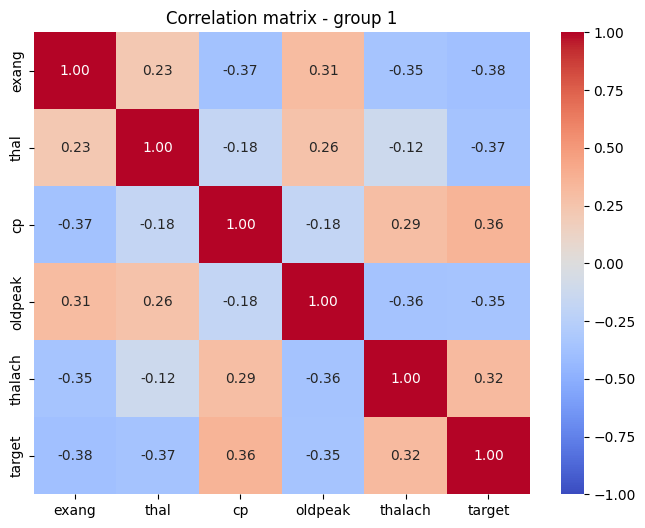


======================= Mutual Information ranking =======================
thal        0.155551
cp          0.097527
ca          0.076807
oldpeak     0.075102
exang       0.073049
slope       0.064149
sex         0.045476
chol        0.040756
thalach     0.018014
restecg     0.010406
fbs         0.003504
age         0.000000
trestbps    0.000000
dtype: float64

======================= Highest correlated pair =======================
('oldpeak', 'slope')
-0.5707412531632219

======================= Logistic regressions with both attributes =======================
[[-0.51599604  0.56414674]]

======================= Logistic regressions with one attribute =======================
oldpeak [[-0.66822531]]
slope [[1.04894894]]


In [45]:
plt.figure(figsize=(10, 8))

# TODO: compute the correlation matrix with a pandas method
corr = df.corr()
corr_without_target = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("======================= Correlation ranking =======================")
print(corr_without_target)

top5 = corr_without_target.head(5).index

# TODO: show it with sns.heatmap(...)
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[list(top5) + ["target"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(f"Correlation matrix - group {GROUP_NUMBER}")
plt.show()

# Mutual Information Ranking
X = df.drop(columns="target")
y = df["target"]

cat_mask = [
    False,  # age
    True,   # sex
    True,   # cp
    False,  # trestbps
    False,  # chol
    True,   # fbs
    True,   # restecg
    False,  # thalach
    True,   # exang
    False,  # oldpeak
    True,   # slope
    True,   # ca
    True    # thal
]
mi = mutual_info_classif(X, y, random_state=S, discrete_features=cat_mask)

mi_ranking = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("\n======================= Mutual Information ranking =======================")
print(mi_ranking)

# Highest correlated attributes
corr = df.drop(columns="target").corr()

corr_abs = corr.abs()
corr_abs = corr_abs.mask(np.eye(corr_abs.shape[0], dtype=bool))
pair = corr_abs.stack().idxmax()

original_corr = corr.loc[pair[0], pair[1]]

print("\n======================= Highest correlated pair =======================")
print(pair)
print(original_corr)

# Logistic regression with both attributes
X_both = df[list(pair)]
y = df["target"]

model_both = LogisticRegression(max_iter=1000)
model_both.fit(X_both, y)

print("\n======================= Logistic regressions with both attributes =======================")
print(model_both.coef_)

# Logistic regression with one attribute
model_1 = LogisticRegression(max_iter=1000)
model_1.fit(df[[pair[0]]], y)

model_2 = LogisticRegression(max_iter=1000)
model_2.fit(df[[pair[1]]], y)

print("\n======================= Logistic regressions with one attribute =======================")
print(pair[0], model_1.coef_)
print(pair[1], model_2.coef_)

**Your answers:**

a) [age, restceg, oldpeak]. To choose my top 5, I would create a correlation matrix of all the columns with "target", as shown above.

b) The only attribute that I expected here was "oldpeak", missing all of the others.
<table>
<tr><th>Attribute</th> <th>Correlation</th></tr>
<tr><td>exang</td><td>-0.384595</td></tr>
<tr><td>thal</td><td>-0.365281</td></tr>
<tr><td>cp</td><td>0.358467</td></tr>
<tr><td>oldpeak</td><td>-0.353332</td></tr>
<tr><td>thalach</td><td>0.318367</td></tr>
</table>

c) It creates a baseline of expectations: the higher the correlation, the more likely an attribute is to have an impact on the target. However, correlation has several limitations. It doesn’t prove that an attribute causes heart disease, doesn’t capture complex or non-linear relationships, and doesn’t account for interactions between multiple attributes. It also doesn’t show how important an attribute will be to the final trained model or how accurately the model will predict heart disease.

d) Correlation is not ideal for categorical attributes such as cp and thal because their numerical values are codes for categories, not actual numerical quantities. For example, cp = 3 is not necessarily "more" chest pain than cp = 1. Pearson correlation assumes that the numerical differences between values have meaning.

The rankings differ considerably between correlation and mutual information. Correlation ranks exang, thal, and cp highest, while mutual information ranks thal, cp and ca highest. This shows that the choice of relationship measure can affect which attributes appear most relevant. Mutual information is particularly useful for categorical attributes because it does not assume that their numerical codes represent meaningful distances or that their relationship with the target is linear.

e) "oldpeak" and "slope" have a correlation of approximately -0.571. When used individually, their coefficients are −0.668 and 1.049, respectively. When both are included, the coefficients decrease to −0.516 and 0.564. This happens because the attributes contain overlapping information. When they are used together, the model can account for the information shared between them, reducing the individual contribution assigned to each coefficient. This is an example of multicollinearity.

## Q3) Train intrinsic explainable models

a) **[Basic]** Complete the preprocessing below (which attributes are scaled, one-hot encoded or kept as they are). Train a logistic model, a decision tree and a kNN model. Report the accuracy and ROC-AUC of each model on your test set.

b) **[Basic]** Why do we scale the attributes for the logistic model and kNN, but not for the decision tree?

> **Hint:** `model.fit(X_train, y_train)`, `model.predict(X_test)`, `model.predict_proba(X_test)[:, 1]`; `accuracy_score`, `roc_auc_score`

In [46]:
X = df.drop(columns="target").astype(float)   # float: needed for PDP in recent scikit-learn
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=S)

# TODO: put every attribute in one of the three lists (use your table from Q1 b)
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]   # numerical attributes: will be scaled
cat_cols = ["cp", "restecg", "slope", "ca", "thal"]   # categorical attributes: will be one-hot encoded
bin_cols = ["sex", "fbs", "exang"]   # binary attributes: kept as they are

preprocessor = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [47]:
logreg = make_pipeline(clone(preprocessor), LogisticRegression(max_iter=1000))
tree = DecisionTreeClassifier(random_state=S)            # a tree needs no scaling
knn = make_pipeline(clone(preprocessor), KNeighborsClassifier(n_neighbors=5))

models = {"logistic": logreg, "tree": tree, "kNN": knn}

# TODO: fit each model on the training data and report accuracy and ROC-AUC on the test set
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")

logistic:
  Accuracy: 0.8116
  ROC-AUC:  0.8882
tree:
  Accuracy: 0.6957
  ROC-AUC:  0.6577
kNN:
  Accuracy: 0.7681
  ROC-AUC:  0.8577


In [48]:
# Your patient: row p of your test set
p = your_patient_index(GROUP_NUMBER, len(X_test))
x_p = X_test.iloc[[p]]
print("Your patient is row", p, "of the test set")
x_p

Your patient is row 1 of the test set


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
201,65.0,1.0,3.0,138.0,282.0,1.0,0.0,174.0,0.0,1.4,1.0,1.0,2.0


**Your answers:**

a) <table>
<tr><th>Model</th> <th>Accuracy</th> <th>ROC-AUC</th></tr>
<tr><td>Logistic Regression</td> <td>0.8116</td> <td>0.8882</td></tr>
<tr><td>Decision Tree</td> <td>0.6957</td> <td>0.6577</td></tr>
<tr><td>kNN</td> <td>0.7681</td> <td>0.8577</td></tr>
</table>

b) Logistic regression and kNN benefit from scaling because their calculations are affected by the magnitude of the attributes. kNN uses distances directly, while scaling also helps logistic regression optimization. Decision trees do not need scaling because they split attributes based on thresholds and are therefore not affected by differences in feature scales.

## Q4) Explaining the logistic model

a) **[Basic]** List the parameters that were fit in the logistic model and explain what they represent.

b) **[Basic]** Compute the odds ratio $e^{\beta}$ of each attribute. For the three most important attributes, write one sentence each, using your own numbers. Example: "if `thalach` increases by one standard deviation, the odds of heart disease are multiplied by ...".

c) **[Basic]** Compute the predicted probability for your patient by hand, using the intercept, the coefficients and the scaled values of your patient. Show the calculation and compare it with `predict_proba`.

d) **[Advanced]** Train the model once on unscaled and once on scaled data. Compare the order of the attributes by $|\beta|$. Why can we not compare coefficients of unscaled data?

e) **[Advanced]** Train the model with `cp` as a number (0, 1, 2, 3) and with `cp` one-hot encoded. How does the explanation of `cp` change? Which version makes sense?

f) **[Advanced]** Use `statsmodels` to get 95% confidence intervals for the odds ratios. Which intervals contain 1? What does that mean for your explanation?

> **Hint:** `clf.coef_`, `clf.intercept_`, `np.exp(clf.coef_)`; scaled values of your patient: `logreg[:-1].transform(x_p)`;
> `import statsmodels.api as sm`; `res = sm.Logit(y, sm.add_constant(X)).fit()`; `np.exp(res.conf_int())`

In [49]:
clf = logreg[-1]                              # the fitted LogisticRegression
names = logreg[:-1].get_feature_names_out()   # attribute names after preprocessing
coef = pd.Series(clf.coef_[0], index=names)
print("intercept:", clf.intercept_[0])
coef.sort_values()

intercept: 1.6306198087756152


ca_1.0        -1.967420
ca_2.0        -1.099469
sex           -0.909961
exang         -0.658642
restecg_2.0   -0.657518
ca_3.0        -0.623320
thal_3.0      -0.606828
slope_1.0     -0.492923
oldpeak       -0.241670
trestbps      -0.203674
chol          -0.119996
cp_1.0        -0.076016
fbs            0.032866
thal_1.0       0.060988
ca_4.0         0.228161
thalach        0.231488
slope_2.0      0.391033
restecg_1.0    0.502469
cp_2.0         0.723376
age            0.748664
cp_3.0         0.852564
thal_2.0       1.008230
dtype: float64

In [50]:
# TODO (b): odds ratios
odds_ratios = np.exp(coef)
print("======================== Odds ratios ===========================")
print(f"{'Attribute':<15} {'Coefficient':>15} {'Odds Ratio':>15}")
for name in coef.abs().sort_values(ascending=False).index:
    print(f"{name:<15} {coef[name]:>15.6f} {odds_ratios[name]:>15.6f}")

# TODO (c): probability of your patient by hand. The scaled values of your patient are:
x_p_scaled = logreg[:-1].transform(x_p)

clf = logreg[-1]

intercept = clf.intercept_[0]
coef = clf.coef_[0]

# z = intercept + b1*x1 + b2*x2 + ...
z = intercept + np.sum(coef * x_p_scaled.iloc[0])

# Sigmoid
probability = 1 / (1 + np.exp(-z))
# With predict_proba()
probability_model = logreg.predict_proba(x_p)[0, 1]

print("\n======================== Scaled patient predictions ========================")
print(x_p_scaled)
print(f"Intercept = {intercept:.6f}")
print(f"z = {z:.6f}")
print(f"p = 1 / (1 + exp(-z)) = {1 / (1 + np.exp(-z)):.6f}")
print(f"Predicted probability (by hand) = {probability:.6f}")
print(f"Predicted probability (predict_proba) = {probability_model:.6f}")

# TODO (d): Compare coefficients with and without scaling
preprocessor_unscaled = ColumnTransformer(
    [("num", "passthrough", num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False,
                           handle_unknown="ignore"), cat_cols),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

logreg_scaled = make_pipeline(
    clone(preprocessor),
    LogisticRegression(max_iter=2000)
)
logreg_unscaled = make_pipeline(
    clone(preprocessor_unscaled),
    LogisticRegression(max_iter=2000)
)

logreg_scaled.fit(X_train, y_train)
logreg_unscaled.fit(X_train, y_train)

coef_scaled = pd.Series(
    logreg_scaled[-1].coef_[0],
    index=logreg_scaled[:-1].get_feature_names_out()
)
coef_unscaled = pd.Series(
    logreg_unscaled[-1].coef_[0],
    index=logreg_unscaled[:-1].get_feature_names_out()
)

print("\n======================== Coefficient magnitude comparison ========================")
print("Scaled data:")
for name in coef_scaled.abs().sort_values(ascending=False).index:
    print(f"{name:<15} β = {coef_scaled[name]:>10.6f}   |β| = {abs(coef_scaled[name]):.6f}")

print("\nUnscaled data:")
for name in coef_unscaled.abs().sort_values(ascending=False).index:
    print(f"{name:<15} β = {coef_unscaled[name]:>10.6f}   |β| = {abs(coef_unscaled[name]):.6f}")

# TODO (e): Compare cp as numerical vs one-hot encoded
num_cols_cp_num = ["age", "trestbps", "chol", "thalach", "oldpeak", "cp"]

preprocessor_cp_num = ColumnTransformer(
    [("num", StandardScaler(), num_cols_cp_num),
     ("cat", OneHotEncoder(drop="first", sparse_output=False,
                           handle_unknown="ignore"), ["restecg", "slope", "ca", "thal"]),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

logreg_cp_num = make_pipeline(
    preprocessor_cp_num,
    LogisticRegression(max_iter=1000)
)
logreg_cp_num.fit(X_train, y_train)


logreg_cp_cat = make_pipeline(
    clone(preprocessor),
    LogisticRegression(max_iter=1000)
)
logreg_cp_cat.fit(X_train, y_train)


coef_cp_num = pd.Series(
    logreg_cp_num[-1].coef_[0],
    index=logreg_cp_num[:-1].get_feature_names_out()
)
coef_cp_cat = pd.Series(
    logreg_cp_cat[-1].coef_[0],
    index=logreg_cp_cat[:-1].get_feature_names_out()
)

print("\n======================== CP as numerical and one-hot encoded ========================")
print(f"Numerical: {coef_cp_num['cp']:.6f}")
print(f"One-hot encoded: ")
for name in coef_cp_cat.index:
    if name.startswith("cp_"):
        print(f"{name:<10} β = {coef_cp_cat[name]:.6f}")

# TODO (f): Use statmodels to get the confidence intervals
X_train_scaled = logreg[:-1].transform(X_train)

# Add intercept
X_train_scaled = sm.add_constant(X_train_scaled)

sm_model = sm.Logit(y_train, X_train_scaled).fit()
conf = sm_model.conf_int()
conf.columns = ["Lower β", "Upper β"]

odds_ratios = np.exp(sm_model.params)
or_lower = np.exp(conf["Lower β"])
or_upper = np.exp(conf["Upper β"])

print("\n======================== Odds Ratios with 95% Confidence Intervals ========================")
print(f"{'Attribute':<15} {'Odds Ratio':>15} {'95% CI Lower':>15} {'95% CI Upper':>15}")
for name in sm_model.params.index:
    if name == "const":
        continue

    print(
        f"{name:<15} "
        f"{odds_ratios[name]:>15.6f} "
        f"{or_lower[name]:>15.6f} "
        f"{or_upper[name]:>15.6f}"
    )

print("\nIntervals containing 1:")
for name in sm_model.params.index:
    if name == "const":
        continue

    if or_lower[name] <= 1 <= or_upper[name]:
        print(f"  {name}")

======================== Odds ratios ===========================
Attribute           Coefficient      Odds Ratio
ca_1.0                -1.967420        0.139817
ca_2.0                -1.099469        0.333048
thal_2.0               1.008230        2.740746
sex                   -0.909961        0.402540
cp_3.0                 0.852564        2.345653
age                    0.748664        2.114174
cp_2.0                 0.723376        2.061380
exang                 -0.658642        0.517554
restecg_2.0           -0.657518        0.518136
ca_3.0                -0.623320        0.536162
thal_3.0              -0.606828        0.545077
restecg_1.0            0.502469        1.652797
slope_1.0             -0.492923        0.610838
slope_2.0              0.391033        1.478508
oldpeak               -0.241670        0.785315
thalach                0.231488        1.260474
ca_4.0                 0.228161        1.256288
trestbps              -0.203674        0.815729
chol                  -

**Your answers:**

a) 
<table>
<tr><th>Parameter</th><th>Coefficient</th><th>Interpretation</th></tr>
<tr><td>Intercept</td><td>1.631</td><td>Log-odds of heart disease when all numerical attributes are at their mean (scaled value 0), binary attributes are 0 and categorical attributes are at their reference category.</td></tr>
<tr><td>age</td><td>0.749</td><td>Change in log-odds for a 1 SD increase in age.</td></tr>
<tr><td>trestbps</td><td>-0.204</td><td>Change in log-odds for a 1 SD increase in resting blood pressure.</td></tr>
<tr><td>chol</td><td>-0.120</td><td>Change in log-odds for a 1 SD increase in cholesterol.</td></tr>
<tr><td>thalach</td><td>0.231</td><td>Change in log-odds for a 1 SD increase in maximum heart rate.</td></tr>
<tr><td>oldpeak</td><td>-0.242</td><td>Change in log-odds for a 1 SD increase in ST depression.</td></tr>
<tr><td>sex</td><td>-0.910</td><td>Change in log-odds for sex = 1 compared with sex = 0.</td></tr>
<tr><td>fbs</td><td>0.033</td><td>Change in log-odds for fbs = 1 compared with fbs = 0.</td></tr>
<tr><td>exang</td><td>-0.659</td><td>Change in log-odds for exang = 1 compared with exang = 0.</td></tr>
<tr><td>cp_1.0 / cp_2.0 / cp_3.0</td><td>-0.076 / 0.723 / 0.853</td><td>Change in log-odds for chest pain type 1 / 2 / 3 compared with type 0.</td></tr>
<tr><td>restecg_1.0 / restecg_2.0</td><td>0.502 / -0.658</td><td>Change in log-odds for restecg 1 / 2 compared with restecg 0.</td></tr>
<tr><td>slope_1.0 / slope_2.0</td><td>-0.493 / 0.391</td><td>Change in log-odds for slope 1 / 2 compared with slope 0.</td></tr>
<tr><td>ca_1.0 / ca_2.0 / ca_3.0 / ca_4.0</td><td>-1.967 / -1.099 / -0.623 / 0.228</td><td>Change in log-odds for ca = 1 / 2 / 3 / 4 compared with ca = 0.</td></tr>
<tr><td>thal_1.0 / thal_2.0 / thal_3.0</td><td>0.061 / 1.008 / -0.607</td><td>Change in log-odds for thal = 1 / 2 / 3 compared with thal = 0.</td></tr>
</table>

b) 
- ca_1.0: For patients in the ca=1 category, the odds of heart disease are multiplied by 0.140 compared with the reference ca category, holding other variables constant.

- ca_2.0: For patients in the ca=2 category, the odds of heart disease are multiplied by 0.333 compared with the reference ca category, holding other variables constant.

- thal_2.0: For patients in the thal=2 category, the odds of heart disease are multiplied by 2.741 compared with the reference thal category, holding other variables constant.

c) The predicted probability calculated by hand is 0.739244, which is identical to the probability obtained using predict_proba. Therefore, the manual calculation correctly reproduces the logistic regression model's prediction for the patient. The model estimates a 73.92% probability of heart disease for this patient.

d) The ordering of the coefficients changes between the scaled and unscaled models, especially for the numerical attributes. For example, age has b=0.7487 when scaled but only b=0.0888 when unscaled, while chol changes from b=-0.1200 to only b=-0.0026. This happens because the unscaled attributes have different units and ranges. A coefficient represents the change in log-odds for a one-unit increase in its corresponding attribute, so the coefficient magnitudes are not directly comparable when the attributes use different scales. After standardization, one unit corresponds to one standard deviation, making the coefficient magnitudes more directly comparable.

e) With cp as a number there is only one coefficient, β = 0.489 per standard deviation. This forces the effect to be linear: going from type 0 to 1 must have the same effect as going from 2 to 3. With one-hot encoding, the model gives cp_1 = −0.076, cp_2 = 0.723, cp_3 = 0.853 compared with cp_0. So type 1 behaves almost like type 0, and types 2 and 3 have a much higher risk — not the equal steps that the numerical version assumes. cp is a type of chest pain, not a quantity, so the one-hot version makes sense.

f) The 95% confidence intervals that don't contain 1 are those of age, ca_1.0, ca_2.0, ca_3.0 and sex. All other intervals contain 1. For these attributes, we cannot say at the 5 % level whether they increase or decrease the odds, so an explanation based on them (e.g. "thal = 2 multiplies the odds by 2.7") is not statistically supported. thal_2.0 also presented 1 within it's interval, but it goes from 0.37 to 3550. Very wide intervals (thal, restecg_2.0, ca_4.0) come from categories with very few patients. The statsmodels model is also not regularised, which is why its odds ratios differ from the scikit-learn ones. Containing 1 does not prove that the attribute has no effect, only that the data is not enough to show it.

## Q5) Explaining the decision tree

a) **[Basic]** Plot the trained tree so that a person can use it to explain a decision. Follow the path of your patient through the tree and write it as one if-then rule.

b) **[Regular]** Train trees with the split methods `"gini"`, `"entropy"` and `"log_loss"`. Plot the accuracies and comment on how the trees differ.

c) **[Regular]** Take the class counts at the root node of your tree. Compute the Gini index, the entropy and the classification error of the root split by hand. Show the calculation.

d) **[Regular]** Plot the train and test accuracy for `max_depth` from 1 to 12. Which depth would you show to a doctor? Explain your choice.

e) **[Advanced]** Train a tree with `max_depth=3` on five bootstrap samples of your training data (seeds $S, S+1, \dots, S+4$). Compare the first two levels of the trees. What does this say about the stability of tree explanations?

> **Hint:** `plot_tree(tree, feature_names=..., class_names=..., filled=True, max_depth=3)`, `export_text(tree, feature_names=...)`;
> `DecisionTreeClassifier(criterion="entropy", random_state=S)`; `tree.decision_path(x_p)`;
> `sklearn.utils.resample(X_train, y_train, random_state=S + i)`

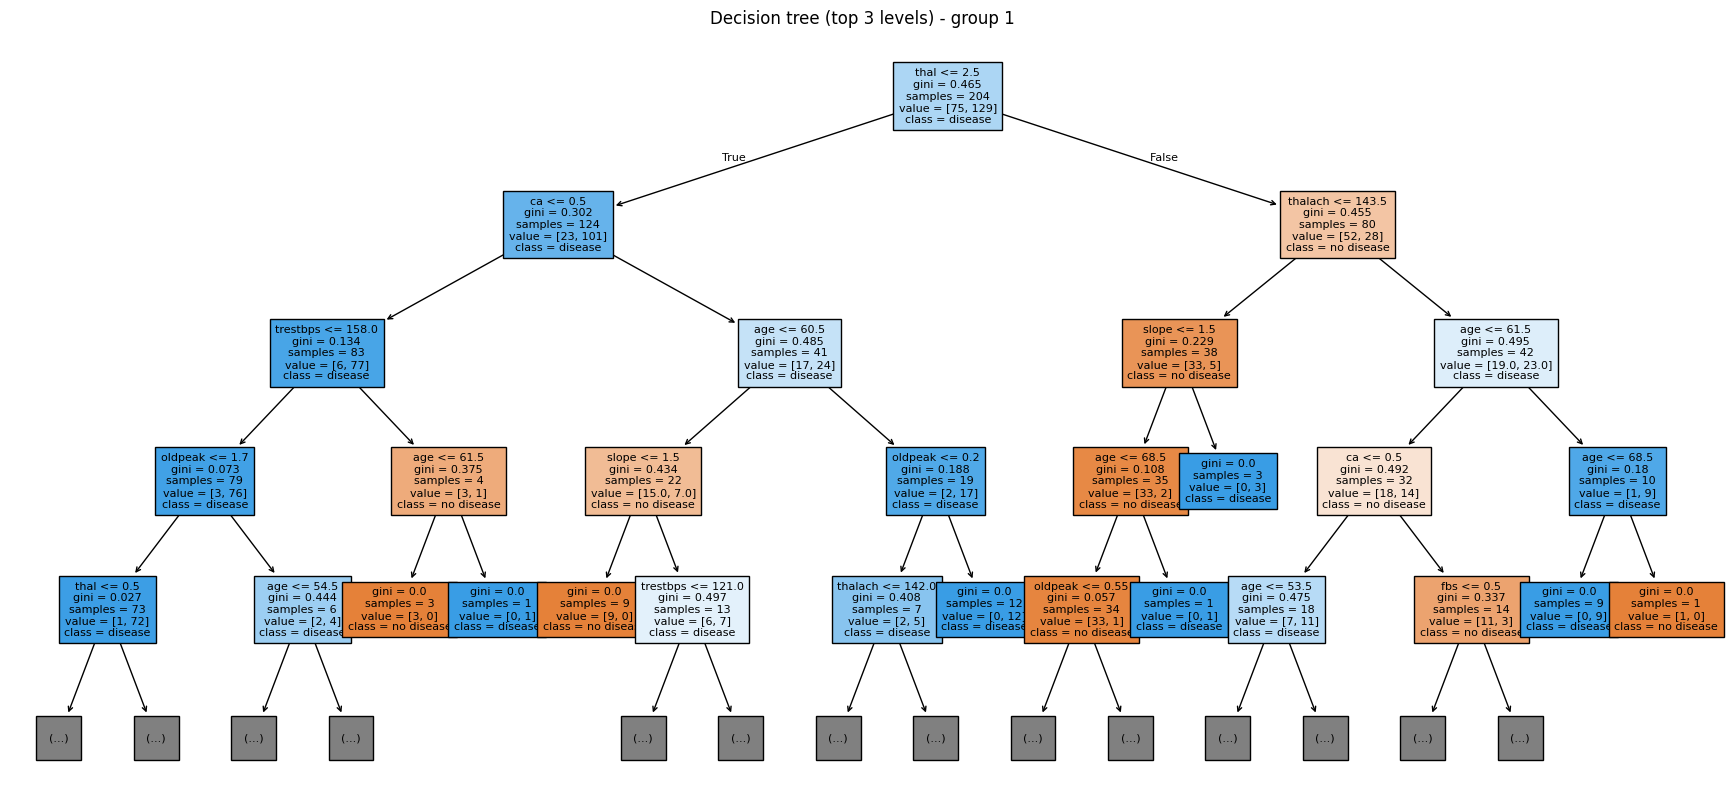

[ 0  1 17 27 33]


In [51]:
plt.figure(figsize=(22, 10))
plot_tree(tree, feature_names=list(X.columns), class_names=["no disease", "disease"],
          filled=True, max_depth=4, fontsize=8)
plt.title(f"Decision tree (top 3 levels) - group {GROUP_NUMBER}")
plt.show()

# Nodes visited by your patient:
print(tree.decision_path(x_p).indices)

gini     : accuracy = 0.6957, depth = 10, leaves = 34, root split = thal <= 2.50
entropy  : accuracy = 0.7391, depth = 10, leaves = 33, root split = thal <= 2.50
log_loss : accuracy = 0.7391, depth = 10, leaves = 33, root split = thal <= 2.50


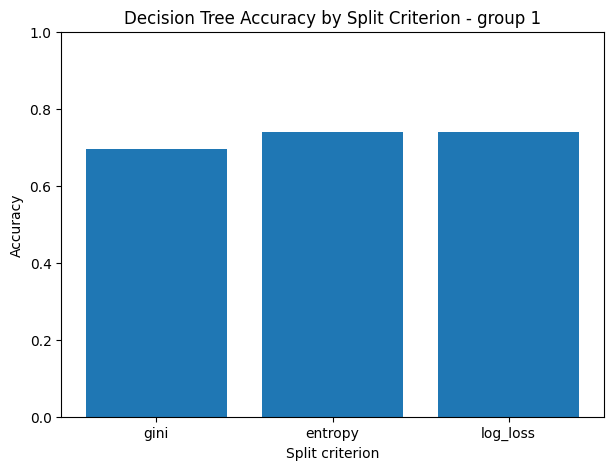

In [52]:
# TODO (b): train trees with criterion "gini", "entropy" and "log_loss"
criteria = ["gini", "entropy", "log_loss"]
accuracies = []

for criterion in criteria:
    t = DecisionTreeClassifier(criterion=criterion, random_state=S)
    t.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, t.predict(X_test))
    accuracies.append(accuracy)

    root = list(X.columns)[t.tree_.feature[0]]
    print(f"{criterion:<9}: accuracy = {accuracy:.4f}, depth = {t.get_depth()}, "
          f"leaves = {t.get_n_leaves()}, root split = {root} <= {t.tree_.threshold[0]:.2f}")

plt.figure(figsize=(7, 5))
plt.bar(criteria, accuracies)
plt.xlabel("Split criterion")
plt.ylabel("Accuracy")
plt.title(f"Decision Tree Accuracy by Split Criterion - group {GROUP_NUMBER}")
plt.ylim(0, 1)
plt.show()

======================== Calculation by hand ========================
Root counts: [75, 129]
Total samples: 204

Gini index:
= 1 - (75/204)² - (129/204)²
= 1 - (0.367647)² - (0.632353)²
= 0.464965

Entropy:
= -(0.367647 × log₂(0.367647) + 0.632353 × log₂(0.632353))
= 0.948848

Classification error:
= 1 - max(0.367647, 0.632353)
= 0.367647


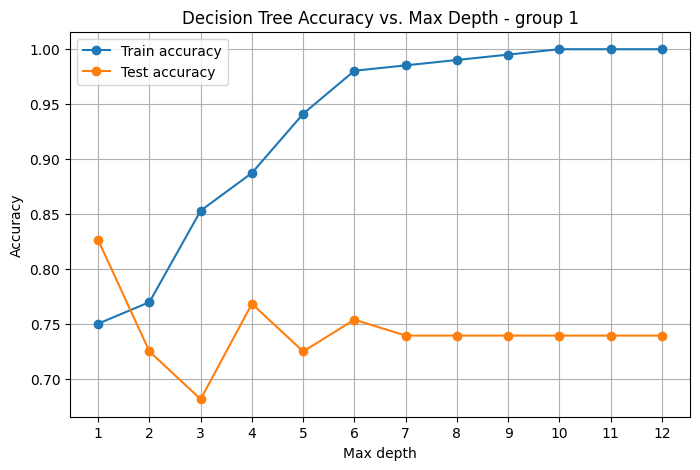


===== Bootstrap 1 =====
|--- ca <= 0.50
|   |--- exang <= 0.50
|   |   |--- trestbps <= 145.00
|   |   |   |--- class: 1
|   |   |--- trestbps >  145.00
|   |   |   |--- class: 1
|   |--- exang >  0.50
|   |   |--- oldpeak <= 0.70
|   |   |   |--- class: 1
|   |   |--- oldpeak >  0.70
|   |   |   |--- class: 0
|--- ca >  0.50
|   |--- age <= 61.50
|   |   |--- slope <= 1.50
|   |   |   |--- class: 0
|   |   |--- slope >  1.50
|   |   |   |--- class: 0
|   |--- age >  61.50
|   |   |--- trestbps <= 137.50
|   |   |   |--- class: 1
|   |   |--- trestbps >  137.50
|   |   |   |--- class: 1


===== Bootstrap 2 =====
|--- exang <= 0.50
|   |--- ca <= 0.50
|   |   |--- age <= 57.50
|   |   |   |--- class: 1
|   |   |--- age >  57.50
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- age <= 61.00
|   |   |   |--- class: 0
|   |   |--- age >  61.00
|   |   |   |--- class: 1
|--- exang >  0.50
|   |--- age <= 62.50
|   |   |--- thalach <= 148.00
|   |   |   |--- class: 0
|   |   |--- t

In [53]:
# Class counts at the root node (for the calculation by hand in (c)).
# In recent scikit-learn versions tree_.value holds class fractions, so multiply by the node size.
n_root = tree.tree_.n_node_samples[0]
counts = np.round(tree.tree_.value[0][0] * n_root).astype(int)

n0, n1 = counts
p0 = n0 / n_root
p1 = n1 / n_root

print("======================== Calculation by hand ========================")
print(f"Root counts: [{n0}, {n1}]")
print(f"Total samples: {n_root}")

gini = 1 - (p0**2 + p1**2)
print("\nGini index:")
print(f"= 1 - ({n0}/{n_root})² - ({n1}/{n_root})²")
print(f"= 1 - ({p0:.6f})² - ({p1:.6f})²")
print(f"= {gini:.6f}")

entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))
print("\nEntropy:")
print(f"= -({p0:.6f} × log₂({p0:.6f}) + "
      f"{p1:.6f} × log₂({p1:.6f}))")
print(f"= {entropy:.6f}")

classification_error = 1 - max(p0, p1)
print("\nClassification error:")
print(f"= 1 - max({p0:.6f}, {p1:.6f})")
print(f"= {classification_error:.6f}")

# TODO (d): train and test accuracy for max_depth = 1, ..., 12
depths = range(1, 13)
train_acc = []
test_acc = []

for depth in depths:
    tree_depth = DecisionTreeClassifier(
        criterion="log_loss",
        max_depth=depth,
        random_state=S
    )
    
    tree_depth.fit(X_train, y_train)
    
    train_acc.append(
        accuracy_score(y_train, tree_depth.predict(X_train))
    )
    test_acc.append(
        accuracy_score(y_test, tree_depth.predict(X_test))
    )

plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, marker="o", label="Train accuracy")
plt.plot(depths, test_acc, marker="o", label="Test accuracy")

plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.title(f"Decision Tree Accuracy vs. Max Depth - group {GROUP_NUMBER}")
plt.xticks(depths)
plt.legend()
plt.grid()
plt.show()

# TODO (e): compare trees trained on five bootstrap samples
trees = []

for seed in range(S, S + 5):
    rng = np.random.RandomState(seed)
    indixes = rng.choice(len(X_train), size=len(X_train), replace=True)

    X_boot = X_train.iloc[indixes]
    y_boot = y_train.iloc[indixes]

    # Train tree
    tree_boot = DecisionTreeClassifier(
        criterion="log_loss",
        max_depth=3,
        random_state=seed
    )
    tree_boot.fit(X_boot, y_boot)

    trees.append(tree_boot)

for i, tree_boot in enumerate(trees):
    print(f"\n===== Bootstrap {S+i} =====")
    print(export_text(
        tree_boot,
        feature_names=list(X_train.columns),
        max_depth=2
    ))

**Your answers:**

a) IF thal <= 2.5 AND ca > 0.5 AND age > 60.5 AND oldpeak > 0.2, THEN class = disease

b) gini reaches an accuracy of 0.6957, while entropy and log_loss both reach 0.7391. In scikit-learn, "log_loss" and "entropy" are the same criterion (Shannon entropy), so these two trees are identical — same splits, same depth, same leaves. The gini tree and the entropy tree start with the same root split (thal <= 2.5) and have the same depth (10), but they differ lower down (34 vs 33 leaves): the two impurity measures rank candidate splits slightly differently, and one different split changes the whole subtree below it. The difference in accuracy on a test set of only 69 patients (3 patients) is small, so it should not be over-interpreted.

c) The calculation is in the print above.

d) I would show the tree with a maximum depth of 1 to the doctor. It has the highest test accuracy (82.61%) among the tested depths and is also the simplest and most interpretable tree. As the depth increases, the training accuracy increases considerably, reaching 100%, while the test accuracy does not improve. This suggests that deeper trees are overfitting the training data.

e) The first two levels of the trees vary substantially between the five bootstrap samples. The root split changes from ca to exang, oldpeak, or thal, while the subsequent splits also differ. This shows that individual decision-tree explanations are relatively unstable: small changes in the training data can produce different decision rules. Therefore, the explanation provided by one particular tree should be interpreted with caution.

## Q6) Explaining kNN

a) **[Basic]** Plot the accuracy for different values of $k$ (odd values from 1 to 51). Comment on how the explanation changes with different values of $k$.

b) **[Basic]** Look at the $k$ nearest neighbours of your patient in the training data (code below). Would this convince a doctor? Why or why not?

c) **[Regular]** Repeat b) without scaling. Which attribute now decides who the neighbours are? Why?

d) **[Advanced]** Find the smallest change in one attribute of your patient that changes the prediction (a counterfactual). Is this change realistic? You may compare with `dice-ml`.

> **Hint:** `knn.set_params(kneighborsclassifier__n_neighbors=k)`;
> `dice_ml.Dice(data, model).generate_counterfactuals(x_p, total_CFs=3, desired_class="opposite")`

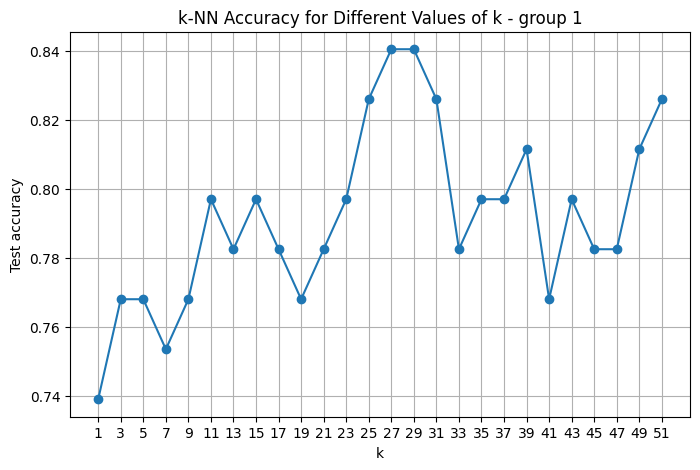

In [54]:
# TODO (a): accuracy for odd k from 1 to 51
ks = range(1, 52, 2)
accuracies = []

for k in ks:
    knn_k = make_pipeline(
        clone(preprocessor),
        KNeighborsClassifier(n_neighbors=k)
    )
    
    knn_k.fit(X_train, y_train)
    y_pred = knn_k.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(ks, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title(f"k-NN Accuracy for Different Values of k - group {GROUP_NUMBER}")
plt.xticks(list(ks))
plt.grid()
plt.show()

In [55]:
# (b) The k nearest neighbours of your patient
knn_clf = knn[-1]
dist, idx = knn_clf.kneighbors(knn[:-1].transform(x_p), n_neighbors=knn_clf.n_neighbors)
neighbours = X_train.iloc[idx[0]].assign(target=y_train.iloc[idx[0]].values, distance=dist[0])
print("======================== k-nearest to the patient ========================")
display(neighbours)

# (c) Repeating (b) without scaling
preprocessor_no_scaling = ColumnTransformer(
    [("num", "passthrough", num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False,
                           handle_unknown="ignore"), cat_cols),
     ("bin", "passthrough", bin_cols)],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

knn_no_scaling = make_pipeline(
    preprocessor_no_scaling,
    KNeighborsClassifier(n_neighbors=5)
)

knn_no_scaling.fit(X_train, y_train)

dist, idx = knn_no_scaling[-1].kneighbors(
    knn_no_scaling[:-1].transform(x_p),
    n_neighbors=5
)

neighbours_no_scaling = X_train.iloc[idx[0]].assign(
    target=y_train.iloc[idx[0]].values,
    distance=dist[0]
)

print("\n======================== k-nearest to the patient without scaling ========================")
display(neighbours_no_scaling)

======================== k-nearest to the patient ========================


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,distance
171,56.0,1.0,0.0,125.0,249.0,1.0,0.0,144.0,1.0,1.2,1.0,1.0,2.0,0,2.356328
69,66.0,1.0,0.0,120.0,302.0,0.0,0.0,151.0,0.0,0.4,1.0,0.0,2.0,1,2.406769
65,63.0,1.0,0.0,130.0,254.0,0.0,0.0,147.0,0.0,1.4,1.0,1.0,3.0,1,2.417764
232,58.0,1.0,1.0,120.0,284.0,0.0,0.0,160.0,0.0,1.8,1.0,0.0,2.0,0,2.460707
44,66.0,0.0,2.0,146.0,278.0,0.0,0.0,152.0,0.0,0.0,1.0,1.0,2.0,1,2.533330



======================== k-nearest to the patient without scaling ========================


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,distance
14,67.0,0.0,2.0,152.0,277.0,0.0,1.0,172.0,0.0,0.0,2.0,1.0,2.0,1,15.425952
193,62.0,0.0,0.0,140.0,268.0,0.0,0.0,160.0,0.0,3.6,0.0,2.0,2.0,1,20.392155
47,54.0,0.0,1.0,132.0,288.0,1.0,0.0,159.0,1.0,0.0,2.0,1.0,2.0,1,20.638798
68,51.0,1.0,0.0,140.0,299.0,0.0,1.0,173.0,1.0,1.6,2.0,0.0,3.0,0,22.339203
256,49.0,0.0,1.0,134.0,271.0,0.0,1.0,162.0,0.0,0.0,1.0,0.0,2.0,1,23.344378


In [28]:
# (d) Finding the smallest change that changes the prediction
cat_cols_dice = cat_cols + bin_cols

df_dice = df.copy().astype(float)
x_p_dice = x_p.copy().astype(float)

data = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=num_cols,
    categorical_features=cat_cols_dice,
    outcome_name="target"
)

model = dice_ml.Model(model=knn, backend="sklearn")
exp = dice_ml.Dice(data, model)

counterfactuals = []

# dice gives out error messages when trying to change the categorical and binary columns
for feature in num_cols:
    try:
        cf = exp.generate_counterfactuals(
            x_p,
            total_CFs=100,
            desired_class="opposite",
            features_to_vary=[feature]
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df

        if cf_df is not None and len(cf_df) > 0:
            counterfactuals.append((feature, cf_df))

    except Exception:
        pass

# Standardizing the results
rows = []
original = x_p.iloc[0]

preprocessor_fitted = knn[:-1][0]
scaler = preprocessor_fitted.named_transformers_["num"]

for feature, cf in counterfactuals:
    for _, row in cf.iterrows():
        cf_value = row[feature]
        absolute_change = abs(cf_value - original[feature])
        standardized_change = absolute_change / scaler.scale_[num_cols.index(feature)]

        rows.append({
            "attribute": feature,
            "original": original[feature],
            "counterfactual": cf_value,
            "absolute_change": absolute_change,
            "standardized_change": standardized_change
        })

comparison = pd.DataFrame(rows).sort_values("standardized_change")
print("\n======================== Searching for counterfactuals ========================")
print("Original patient:")
display(x_p)
display(comparison)

100%|██████████| 1/1 [00:00<00:00, 21.25it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  2.36it/s]


======================== Searching for counterfactuals ========================
Original patient:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
201,65.0,1.0,3.0,138.0,282.0,1.0,0.0,174.0,0.0,1.4,1.0,1.0,2.0


,attribute,original,counterfactual,absolute_change,standardized_change
100,chol,282.0,255.2,26.8,0.525019
75,chol,282.0,255.1,26.9,0.526978
55,chol,282.0,255.0,27.0,0.528937
91,chol,282.0,254.6,27.4,0.536773
76,chol,282.0,253.6,28.4,0.556363
...,...,...,...,...,...
203,oldpeak,1.4,5.9,4.5,3.720334
218,oldpeak,1.4,6.0,4.6,3.803008
224,oldpeak,1.4,6.1,4.7,3.885682
207,oldpeak,1.4,6.2,4.8,3.968357


**Your answers:**

a) Small values of k make the prediction depend strongly on a few nearby training observations, making the explanation more local and sensitive to individual observations. As k increases, more observations contribute to the prediction, making the explanation more general and less sensitive to individual observations. In this experiment, the highest test accuracy is 84.06% for k = 27 and k = 29.

b) Even with scaling and encoding, this would not strongly convince a doctor because the five nearest neighbours are split between 3 patients with target 1 and 2 with target 0, providing no clear consensus. Moreover, Euclidean distance gives equal importance to all features, even though some clinical indicators may be more relevant to heart disease than others. Therefore, k-NN provides a prediction based on similarity to previous patients, but it does not provide an interpretable medical explanation based on pathophysiology or established clinical risk factors.

c) Without scaling, the neighbours are mainly determined by attributes with larger numerical ranges, particularly chol (cholesterol). This happens because Euclidean distance is calculated directly from the feature values, so a large difference in a high-range attribute contributes much more to the distance than a difference in a low-range or binary attribute. Therefore, without scaling, the nearest neighbours can be determined more by the numerical scale of an attribute than by its actual diagnostic relevance.

d) The smallest counterfactual found changes chol from 282.0 to 255.2, a decrease of 26.8. After standardization, this corresponds to a change of approximately 0.53 standard deviations. This change is sufficient to change the kNN model's prediction. The change is plausible, as cholesterol levels can change over time, although a decrease of 26.8 is still a substantial change. Therefore, the counterfactual is reasonably realistic as a change that could occur over time, but it should not be interpreted as a direct medical recommendation.

## Q7) Reflection

a) **[Basic]** Use the decision tree to explain the prediction for your patient (i) to the patient and (ii) to a doctor. What is different between the two explanations?

b) **[Regular]** Assess the decision tree on completeness, comprehensibility and stability, based on what you saw in this lab.

**Your answers:**

a) (i) "Based on your assessment, we looked at key indicators of your heart health. Your stress test result (thal = 2.0) showed patterns that require closer attention. Looking further, your test identified the presence of major blood vessels with reduced flow (ca = 1.0), and at 65 years old, your heart's electrical recovery after exertion (oldpeak = 1.4) indicates that your heart muscle is under strain during physical activity. When we combine these factors, the diagnostic model indicates a high likelihood of heart disease."

(ii) "The decision tree classifies row 201 as disease based on the following decision path:
1. thal <= 2.5 (2.0 <= 2.5 -> True)
2. ca <= 0.5 (1.0 > 0.5 -> False)
3. age <= 60.5 (65.0 > 60.5 -> False)
4. oldpeak <= 0.2 (1.4 > 0.2 -> False)

The patient presents with fixed thallium defect criteria, fluoroscopy indicating 1 major vessel colored, age over 60.5, and an ST depression (oldpeak) of 1.4 mm. This combination routes directly to a pure terminal node for coronary artery disease."

The differences between the explanations are in the language, terminology and focus. The patient explanation translates abstract feature names and numerical thresholds (thal, ca, oldpeak, gini) into clinical concepts (blood flow, vessel blockage, heart strain). The doctor explanation uses exact feature variable names, precise numerical cutoffs, and standard medical terminology (e.g., ST depression, fluoroscopy). The patient's communication emphasizes personal health context, while the doctor's communication focuses on diagnostic rigor and decision-path logic for rapid peer verification.

b) Completeness is high because decision trees exhaustively cover the feature space. Every valid combination of patient inputs follows a deterministic, uninterrupted path through the conditional split nodes until reaching a single leaf prediction, leaving no unhandled cases.

Comprehensibility is high at the top levels but drops to moderate across the full tree. While individual decision pathways are easily translated into intuitive if-then rules, the full-depth tree contains numerous branches and split criteria that become visually cluttered and tedious for a human to trace.

Stability is low due to the inherent sensitivity of unpruned decision trees. Minor variations in the training dataset, such as altering the train-test split or removing a few samples, can radically alter the root-level split selection (e.g., swapping thal for another attribute), causing a cascade effect that restructures the entire downstream hierarchy.   